# Phase 5 — Validation, calibration, uncertainty, and fairness

Goal: report final numbers for the models already chosen in Phase 3
(gradient boosting) and Phase 4 (Cox, dummy-coded cancer) on data that played
**no role whatsoever** in choosing them. Phase 3/4 used cross-validation on
the full cohort to *compare* candidates — the right tool for that job. This
notebook is different: a genuinely held-out test set, split once and touched
only for final reporting, plus bootstrap uncertainty and subgroup fairness.
All splitting, calibration, bootstrap, and subgroup logic lives in
`support_survival.validate`; this notebook only calls it and narrates.

In [1]:
from support_survival import data, features, models, evaluate, validate

df = data.load()
feat = features.build_features(df)

train, val, test = validate.split_train_val_test(feat, test_size=0.2, val_size=0.2, random_state=42)
len(train), len(val), len(test)

(5323, 1775, 1775)

In [2]:
train["event"].mean(), val["event"].mean(), test["event"].mean()

(np.float64(0.6802554950216043),
 np.float64(0.6805633802816902),
 np.float64(0.68))

**Reading this:** 5,323 / 1,775 / 1,775 patients (train / validation / test),
event rate ~68% preserved in all three (stratified split). `test` is set
aside now and used exactly twice below: once to report calibration, and once
for bootstrap confidence intervals, subgroup performance, and error analysis.
It is never used to fit a model, tune a hyperparameter, or pick a
recalibrator.

## Fit the chosen model on `train` only

Same gradient boosting configuration selected in Phase 3 via cross-validation
— no new tuning happens here, so there is no opportunity for `test` (or even
`val`) to influence which model or hyperparameters get used.

In [3]:
cols = evaluate.feature_columns(feat)
gb = models.gradient_boosting()
gb.fit(train[cols], train["event"])

proba_val = gb.predict_proba(val[cols])[:, 1]
proba_test_raw = gb.predict_proba(test[cols])[:, 1]
y_val = val["event"].to_numpy()
y_test = test["event"].to_numpy()

validate.brier(y_test, proba_test_raw)

0.1944677084684372

## Calibration and recalibration

A Brier score of ~0.19 alone doesn't say *how* a model is miscalibrated —
the reliability diagram does. We also check whether an isotonic recalibrator
(fit strictly on `val`, never on `test`) improves it.

In [4]:
ir = validate.fit_isotonic_recalibrator(proba_val, y_val)
proba_test_recalibrated = ir.predict(proba_test_raw)
validate.brier(y_test, proba_test_recalibrated)

0.19420626759529114

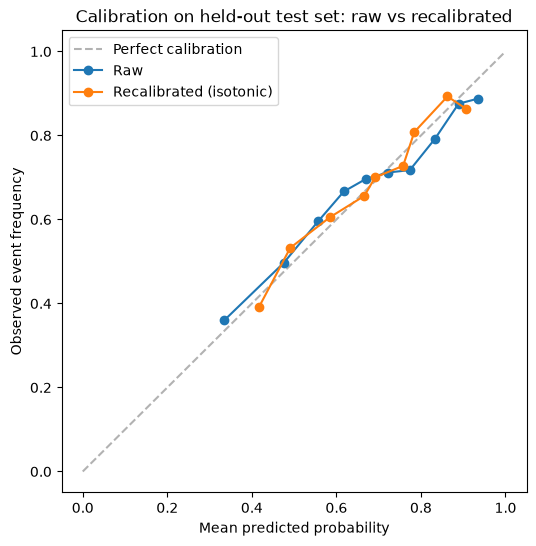

In [5]:
_ = validate.plot_calibration_before_after(
    y_test, proba_test_raw, proba_test_recalibrated,
    save_path=evaluate.REPORTS_DIR / "calibration_test_before_after.png",
)

**Reading this:** recalibration barely moves the needle — Brier 0.1945 raw
vs 0.1942 recalibrated, and the reliability diagram shows both curves within
roughly 1-5 percentage points of the diagonal at every bin. This matches the
Phase 3 finding that gradient boosting was already reasonably well-calibrated
on this cohort; there's no meaningful miscalibration here for isotonic
regression to fix. We report the **raw** model's predictions as final below
— recalibration was checked, not skipped, and simply wasn't needed. The
important methodological point is *where* the recalibrator was fit: on
`val`, never on `test`, so nothing about the test set influenced this
prediction before it was scored.

## Uncertainty: bootstrap confidence intervals

Point estimates alone hide how much the exact number would move with a
different sample of patients. Both bootstraps resample only from `test`.

In [6]:
from sklearn.metrics import roc_auc_score

auroc_ci = validate.bootstrap_ci(y_test, proba_test_raw, roc_auc_score, n_boot=2000, random_state=42)
brier_ci = validate.bootstrap_ci(y_test, proba_test_raw, validate.brier, n_boot=2000, random_state=42)
{"auroc": auroc_ci, "brier": brier_ci}

{'auroc': {'point': 0.6985556670595238,
  'lower': 0.6722357653556656,
  'upper': 0.7235644779104131},
 'brier': {'point': 0.1944677084684372,
  'lower': 0.185649261623621,
  'upper': 0.20367312990128994}}

**Reading this:** AUROC 0.699 (95% CI 0.672–0.724), Brier 0.194 (95% CI
0.186–0.204) on the held-out test set — both intervals are reasonably tight
given 1,775 test patients, and the point estimate lands right where Phase
3's cross-validated estimate (0.700) said it would. Consistency between the
CV estimate and this independent held-out estimate is itself a good sign:
if they disagreed sharply, that would suggest the CV comparison in Phase 3
was optimistic.

In [7]:
df2 = models.encode_cancer_stage(df)
train_cox, val_cox, test_cox = validate.split_train_val_test(df2, test_size=0.2, val_size=0.2, random_state=42)
cox_covariates = ["age", "n_comorbidities", "mean_bp", "heart_rate", "serum_creatinine", "wbc",
                   "cancer_present", "cancer_metastatic"]
cph = models.fit_cox(train_cox, cox_covariates)

concordance_ci = validate.bootstrap_cox_concordance_ci(
    cph, test_cox.reset_index(drop=True), cox_covariates, n_boot=1000, random_state=42
)
concordance_ci

{'point': 0.6083896375734108,
 'lower': 0.5900338573492179,
 'upper': 0.6260430365941411}

**Reading this:** Cox concordance 0.608 (95% CI 0.590–0.626) on the same
held-out test set — consistent with Phase 4's 5-fold CV estimate (0.598),
comfortably inside the plausible range, nowhere near the 0.85+ that would
demand a leakage investigation.

## Subgroup performance and calibration: age band and sex

AUROC (discrimination) and Brier score (calibration) computed separately per
subgroup, on `test`, using the raw model's predictions.

In [8]:
import pandas as pd

test_r = test.reset_index(drop=True)
proba_test = proba_test_raw
test_r["age_band"] = pd.cut(test_r["age"], bins=[0, 50, 65, 75, 85, 120],
                              labels=["<50", "50-64", "65-74", "75-84", "85+"])

validate.subgroup_report(test_r, "event", proba_test, "age_band")

,group,n,event_rate,auroc,brier
0,50-64,524,0.719466,0.664519,0.193980
1,65-74,465,0.709677,0.656611,0.193849
2,75-84,338,0.760355,0.594898,0.181909
3,85+,85,0.729412,0.544881,0.204970
4,<50,363,0.498623,0.740939,0.205199


In [9]:
validate.subgroup_report(test_r, "event", proba_test, "sex")

,group,n,event_rate,auroc,brier
0,0.0,997,0.694082,0.717810,0.185988
1,1.0,778,0.661954,0.674333,0.205335


**Reading this — a real, worth-documenting gap:** discrimination degrades
sharply with age: AUROC 0.741 for under-50s down to **0.545 for patients 85+**
— barely better than random ranking in the oldest band, even though Brier
score stays fairly flat across bands (~0.18–0.21). The model can still be
roughly calibrated on average for the oldest patients while being nearly
useless at *ranking* them by risk — calibration and discrimination are
different failure modes, and this cohort shows exactly why checking both
matters. By sex: AUROC 0.718 for code `0` (997 patients) vs 0.674 for code
`1` (778 patients) — a smaller but present gap. `sex` is documented only as
"encoded" in the source data (`data.DESCRIPTIONS`); which code maps to male
vs female isn't independently confirmed, so this is reported by code value
without asserting which is which. Both findings belong in the model card as
disclosed limitations, not just here.

## Error analysis: the worst-predicted patients

The patients where the model was most confidently wrong, in both directions.

In [10]:
worst_overpredicted = validate.worst_predictions(
    test_r, "event", proba_test, ["age", "cancer", "n_comorbidities"], n=15
)
worst_overpredicted["cancer"].value_counts()

cancer
0.0    13
2.0     1
1.0     1
Name: count, dtype: int64

In [11]:
test_r["cancer"].value_counts(normalize=True).round(3)

cancer
1.0    0.672
0.0    0.197
2.0    0.131
Name: proportion, dtype: float64

**Reading this:** among the 15 patients the model was most wrong about in
the "predicted very high risk, but survived" direction, 13/15 have
`cancer=0` — vastly overrepresented versus the 19.7% base rate in the test
set. This is the Phase 4 finding resurfacing here: `cancer=0` is the
highest-mortality group in this cohort (other severe SUPPORT diagnoses, not
"healthy"), so the model has learned a strong "cancer=0 → very high risk"
prior — usually correct, but confidently wrong for the minority of `cancer=0`
patients who survive anyway.

In [12]:
tmp = test_r[["age", "cancer", "n_comorbidities", "event"]].copy()
tmp["predicted_proba"] = proba_test
tmp[tmp["event"] == 1].nsmallest(10, "predicted_proba")

,age,cancer,n_comorbidities,event,predicted_proba
1148,19.85199,1.0,1.0,1,0.139479
1585,25.47299,1.0,1.0,1,0.167645
326,40.55298,1.0,1.0,1,0.181694
776,47.48297,1.0,0.0,1,0.197717
461,40.09900,1.0,2.0,1,0.256867
199,33.19397,1.0,1.0,1,0.259840
1620,54.23700,1.0,0.0,1,0.266789
272,35.31799,1.0,2.0,1,0.273302
389,51.36200,1.0,2.0,1,0.275424
1632,42.93500,1.0,2.0,1,0.282682


**The mirror-image error:** the patients died despite a *low* predicted
risk are overwhelmingly young (20s-50s) with `cancer=1` (non-metastatic) and
0-2 comorbidities — exactly the profile with the best average prognosis in
this cohort. Same story as above, opposite direction: the model's strongest,
generally-correct priors (young + non-metastatic cancer = low risk;
`cancer=0` = high risk) are also its biggest liability whenever a patient is
the exception to the pattern. This is a coherent, clinically explainable
error pattern — not a random or bug-like one.

## Confirming test-set isolation

`test` was created once, in the second code cell of this notebook
(`validate.split_train_val_test`), and used in exactly three places after
that: (1) scoring calibration/Brier for both raw and recalibrated
predictions, (2) the bootstrap confidence intervals for AUROC, Brier, and Cox
concordance, and (3) the subgroup report and error analysis above. At no
point was `test` used to fit a model, choose a hyperparameter, or fit the
isotonic recalibrator (that used `val`). If any of those decisions had
touched `test`, the numbers above would be optimistic in a way this notebook
could no longer detect on its own — which is exactly why the split exists.

## Summary for Phase 6

- Gradient boosting, trained on `train` only: held-out AUROC 0.699 (95% CI
  0.672–0.724), Brier 0.194 (95% CI 0.186–0.204) — consistent with Phase 3's
  CV estimate.
- Recalibration checked (fit on `val` only) but not needed — the raw model is
  the one to serve.
- Cox concordance on the same held-out test set: 0.608 (95% CI 0.590–0.626),
  consistent with Phase 4's CV estimate.
- Documented limitation: discrimination degrades sharply for patients 85+
  (AUROC 0.545) — flag this age range as low-confidence if this model is ever
  used to inform a serving decision.
- Error patterns are clinically coherent (driven by `cancer` and age), not
  random — a good sign the model learned real structure rather than noise.
- Phase 6: wrap the trained model in a FastAPI service, reusing
  `features.build_features` unchanged between training and serving.